In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt



root_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "utils").exists()), None)
if root_path is None:
    raise FileNotFoundError("Could not locate project root containing 'utils' directory")
sys.path.append(str(root_path))

from utils.helpers import load_data
from utils.CBM_scores_aggregated import cbm_total_score1, cbm_total_score2

In [2]:
df = load_data("../data/CBM_format/IN1020_2025konte_CBM.csv")
df.head()

Data loaded successfully from ../data/CBM_format/IN1020_2025konte_CBM.csv


,student_id,max_question_score,question_number,question_title,question_duration_sec,auto_score_per_question,total_score,auto_score,answer_alternative,confidence_level
0,31,1.0,2.1,H25K - CBA - PC,32,1.0,68.25,18.0,1,100.0
1,31,1.0,2.1,H25K - CBA - PC,32,1.0,68.25,18.0,4,0.0
2,31,1.0,2.1,H25K - CBA - PC,32,1.0,68.25,18.0,3,0.0
3,31,1.0,2.1,H25K - CBA - PC,32,1.0,68.25,18.0,5,0.0
4,31,1.0,2.1,H25K - CBA - PC,32,1.0,68.25,18.0,2,0.0


### Plot total auto score

Number of unique students: 68


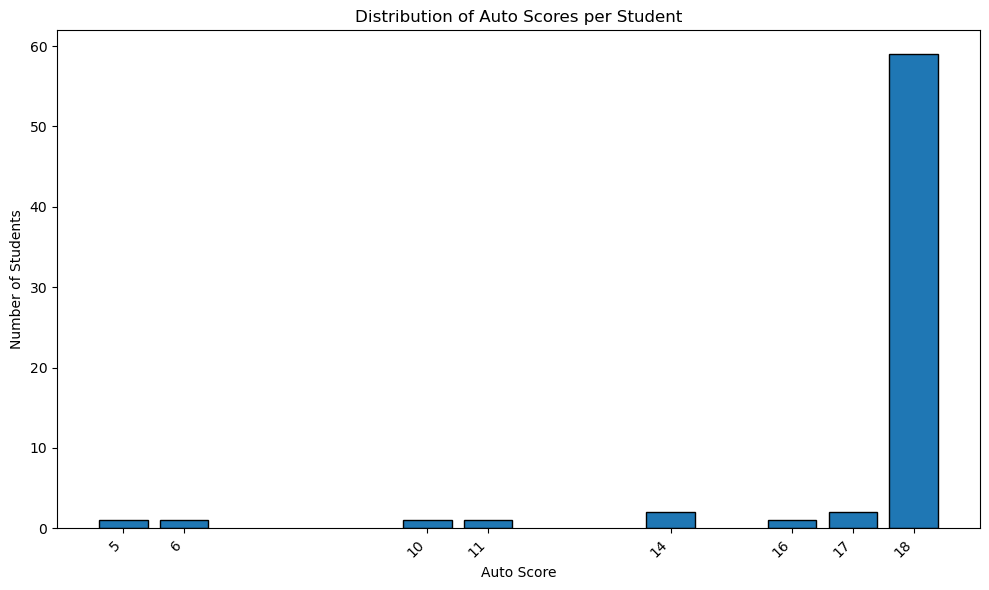

In [3]:
student_scores = df.drop_duplicates(subset=["student_id"])[["student_id", "auto_score"]]

print(f"Number of unique students: {len(student_scores)}")

#By using value_counts().sort_index(), each bar is drawn at the exact score value that students actually received
score_counts = student_scores["auto_score"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(score_counts.index, score_counts.values, width=0.8, edgecolor="black", align="center")
plt.xticks(score_counts.index, rotation=45, ha="right")
plt.xlabel("Auto Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Auto Scores per Student")
plt.tight_layout()
plt.show()


### CBM 1

In [4]:
df_CBM1 = cbm_total_score1(df)
df_CBM1[["student_id", "part2_cbm_score"]].drop_duplicates(subset=["student_id"]).head()

,student_id,part2_cbm_score
0,31,875.0
75,36,1775.0
150,25,650.0
225,56,1037.5
300,57,1775.0


Number of unique students: 68


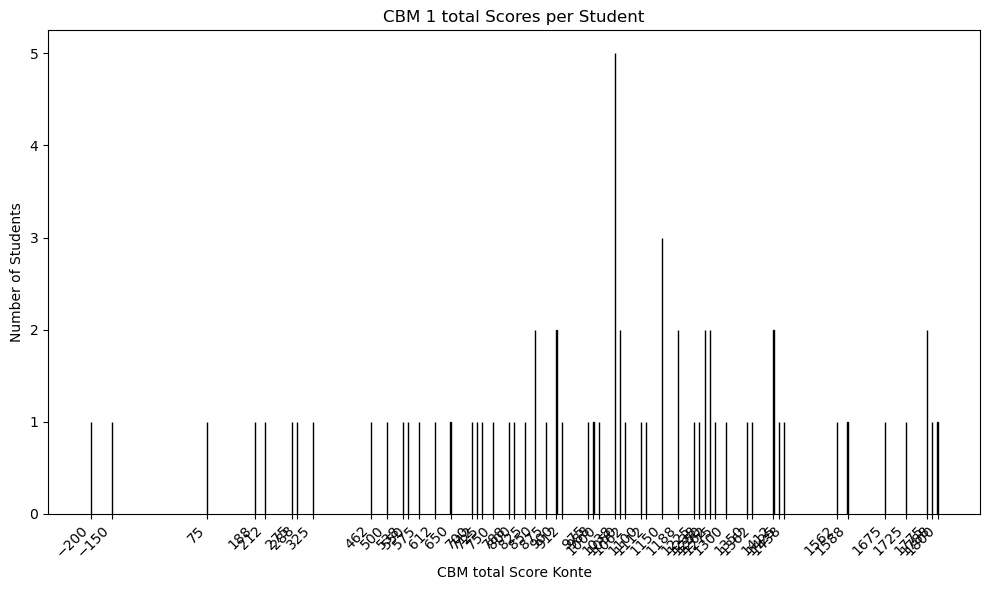

In [5]:
student_scores = df_CBM1.drop_duplicates(subset=["student_id"])[["student_id", "part2_cbm_score"]]

print(f"Number of unique students: {len(student_scores)}")

#By using value_counts().sort_index(), each bar is drawn at the exact score value that students actually received
score_counts = student_scores["part2_cbm_score"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(score_counts.index, score_counts.values, width=0.4, edgecolor="black", align="center")
plt.xticks(score_counts.index, rotation=45, ha="right")
plt.xlabel("CBM total Score Konte")
plt.ylabel("Number of Students")
plt.title("CBM 1 total Scores per Student")
plt.tight_layout()
plt.show()


### CBM 2

In [6]:
# df_CBM2 = cbm_total_score2(df)
# df_CBM2[["student_id", "part2_cbm_score"]].drop_duplicates(subset=["student_id"])

# student_scores = df_CBM2.drop_duplicates(subset=["student_id"])[["student_id", "part2_cbm_score"]]

# print(f"Number of unique students: {len(student_scores)}")

# #By using value_counts().sort_index(), each bar is drawn at the exact score value that students actually received
# score_counts = student_scores["part2_cbm_score"].value_counts().sort_index()

# plt.figure(figsize=(10, 6))
# plt.bar(score_counts.index, score_counts.values, width=0.4, edgecolor="black", align="center")
# plt.xticks(score_counts.index, rotation=45, ha="right")
# plt.xlabel("CBM total Score Konte")
# plt.ylabel("Number of Students")
# plt.title("CBM 2 total Scores per Student")
# plt.tight_layout()
# plt.show()